In [1]:
%load_ext autoreload
%autoreload 2

fig_num = 4 # change this to the figure number
analysis_name = "hpc_pc_analysis" # change this to the subfolder it should save to

subject = "Wallie"
date = "20220912"
nwb_file_name = f"{subject}{date}_.nwb"
epoch_interval = "10_lineartrack"
key = {"nwb_file_name": nwb_file_name,}

from spyglass.common import PositionIntervalMap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pos_interval = (PositionIntervalMap() &{**key, "interval_list_name": epoch_interval}).fetch1("position_interval_name")

/home/sambray/.local/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # requires setuptools<82
[2026-09-17 14:40:23,356][INFO]: DataJoint 0.14.9 connected to sambray@lmf-db.cin.ucsf.edu:3306


In [2]:
from spyglass.decoding.v1.c3po import Model

model_key = {**key, "model_name":"wallie_linear_dim20_noSmooth_v0",
              "marks_group_name":"10_lineartrack_wf_norm1000"}

# model_key = {**key, 'model_name': 'wallie_linear_dim20_10Smooth_v0'}


analysis = (Model & model_key).fetch_c3po_analysis(checkpoint = None)
analysis.fit_context_pca()
t_interp = np.arange(analysis.t[0], analysis.t[-1], 0.001)
analysis.interpolate_context(t_interp)
analysis.embed_context_pca()

from c3po.analysis.analysis import figure_directory
from pathlib import Path
fig_dir = Path(figure_directory) / f"Fig{fig_num}/{analysis_name}"/f"{subject}_{date}_{epoch_interval}_{model_key['model_name']}"
fig_dir.mkdir(parents=True, exist_ok=True)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/sambray/.local/lib/python3.10/site-packages/traitlets/

x shape (1, 5)


2026-09-17 14:40:44.566035: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-09-17 14:40:46.276595: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceM

# Load data

### position

In [3]:
from utils.load_hpc_data import load_position_data

pos_data = load_position_data(nwb_file_name, epoch_interval)

pos_df = pos_data["pos_df"]
pos_times = pos_data["pos_times"]
pos = pos_data["pos"]
vel = pos_data["vel"]
all_running_intervals = pos_data["all_running_intervals"]
left_running_intervals = pos_data["left_running_intervals"]
right_running_intervals = pos_data["right_running_intervals"]


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Devic

In [4]:
from spyglass.position.v1 import TrodesPosV1
epoch_key = {
    "nwb_file_name": nwb_file_name,
    "interval_list_name": epoch_interval,
}
pos_interval = (PositionIntervalMap() & epoch_key).fetch1("position_interval_name")
pos_key = {
    "nwb_file_name": nwb_file_name,
    "interval_list_name": pos_interval,
    "trodes_pos_params_name": "single_led_upsampled",
}
pos_df_2d = (TrodesPosV1() & pos_key).fetch1_dataframe()

[14:41:18][WARNING] Spyglass: Upsampled position data, frame indices are invalid. Setting add_frame_ind=False
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: Us

### LFP

In [5]:
from utils.load_hpc_data import load_lfp_data

lfp_data = load_lfp_data(nwb_file_name, epoch_interval)
theta_phase_df = lfp_data["theta_phase_df"]
fg_phase_df = lfp_data["fg_phase_df"]
sg_phase_df = lfp_data["sg_phase_df"]


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Devic

### SortedData

In [6]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup

spikes_key = {
    **key,
    "sorted_spikes_group_name": epoch_interval,
}
SortedSpikesGroup() & spikes_key
spikes_list, unit_ids = (SortedSpikesGroup() & spikes_key).fetch_spike_data(
    spikes_key, return_unit_ids=True
)

[14:41:48][WARNING] Spyglass: Missing code for CurationV2
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-pa

### Ripples

In [7]:
from spyglass.ripple.v1 import RippleTimesV1, RippleLFPSelection

ripple_df = (
    RippleTimesV1()
    & key
    & f"target_interval_list_name LIKE '%{pos_interval}%'"
).fetch1_dataframe()
ripple_intervals = ripple_df[["start_time", "end_time"]].values

/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Devic

### DIO Behavior Marks

In [8]:
from spyglass.common import DIOEvents

event_types = ["poke", "reward"]
behavior_events = {}
behavior_events_detailed = {}
for dio in event_types:
    dio_query = DIOEvents() & key & f"dio_event_name LIKE '%{dio}%'"
    marks = []
    for dio_name in dio_query.fetch("dio_event_name"):
        nwb = (DIOEvents() & key & f"dio_event_name='{dio_name}'").fetch_nwb()[0]
        obj = nwb["dio"]
        t = obj.timestamps[:]
        data = obj.data[:]
        marks.extend(t[data == 1])
        behavior_events_detailed[dio_name] = t[data == 1]
    marks = np.array(marks)
    behavior_events[dio] = marks


[2026-09-17 14:42:45,187][WARNING]: Skipped checksum for file with hash: bbc80993-55d4-5fc6-0ca9-d62eecdb0f15, and path: /stelmo/nwb/raw/Wallie20220912_.nwb
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.

In [9]:
from c3po.tables.trials_parsing import Trials
trials_df = (Trials() & key).fetch_nwb()[0]['trials']
trial_intervals = trials_df[["run_start", "t_poke"]].values

if trials_df.trial_type.values[0] == "right":
    left_inds = trials_df[trials_df.trial_type == "left"].index.values
    right_inds = trials_df[trials_df.trial_type == "right"].index.values
    trials_df.loc[left_inds, "trial_type"] = "right"
    trials_df.loc[right_inds, "trial_type"] = "left"

/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines Camer

In [10]:
trials_df.iloc[0]

run_start      1663021531.691022
t_poke         1663021557.463852
origin                 left_port
destination           right_port
trial_type                  left
Name: 0, dtype: object

# Analyze

In [11]:
# analysis.fit_context_pca(fit_intervals=all_running_intervals)
analysis.fit_context_pca()
analysis.embed_context_pca()

# power spectrums

In [12]:
window_size = 60000
nfft = 100000

f, mid, lo, hi = analysis.power_spectrum(
    # intervals=trial_intervals,
    window_size=window_size,
    nfft=nfft,
    pca=True
)

theta_window_size = 1000
f_theta, mid_theta, lo_theta, hi_theta = analysis.power_spectrum(
    intervals=trial_intervals,
    window_size=theta_window_size,
    nfft=nfft,
    pca=True,
    sourced_data = (theta_phase_df.index.values, theta_phase_df["signal"].values[:,None],)
)

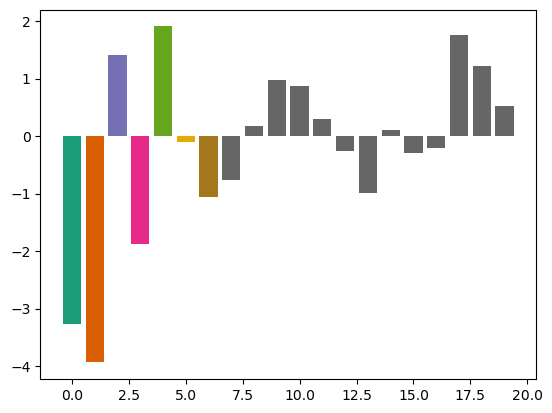

In [14]:
behavior_freq_rng = (1e-10,1)
theta_freq_rng = (5,11)

behavior_inds = np.where((f > behavior_freq_rng[0]) & (f < behavior_freq_rng[1]))[0]
theta_inds = np.where((f > theta_freq_rng[0]) & (f < theta_freq_rng[1]))[0]

mid_density = (mid * f).T

peak_behavior_power = np.nanmax(mid_density[behavior_inds], axis=0)
peak_theta_power = np.nanmax(mid_density[theta_inds], axis=0)

power_ratio = peak_theta_power / peak_behavior_power

for i in range(20):
    color = plt.cm.Dark2(i/8)
    plt.bar(i, np.log2(power_ratio[i]), color=color)



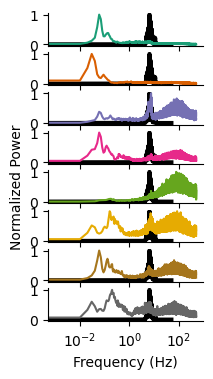

In [15]:
plot_f = f.copy()
plot_mid = mid * plot_f
plot_mid = plot_mid / np.max(plot_mid)
plot_mid = plot_mid / np.max(plot_mid,axis=1, keepdims=True)

plot_f_theta = f_theta.copy()
plot_mid_theta = mid_theta * plot_f_theta
plot_mid_theta = plot_mid_theta / np.max(plot_mid_theta)


pc_plot = slice(0,3)
fig, ax = plt.subplots(nrows=8, ncols=1, figsize=(2,4), sharex=True)
for i, a in enumerate(ax):
    color = plt.cm.Dark2(i/8)
    a.plot(f, plot_mid[i].T, c=color)
    a.plot(f_theta, plot_mid_theta.T, c='k',lw=3,zorder = -1)
    a.spines[['top', 'right']].set_visible(False)

plt.xscale('log')
# plt.yscale('log')
# plt.xlim(-1,15)
plt.xlabel("Frequency (Hz)")
ax[len(ax)//2].set_ylabel("Normalized Power")
fig.savefig(fig_dir / f"power_spectrum.svg", dpi=300, bbox_inches='tight')

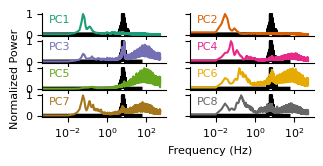

In [24]:
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.size'] = 8
plot_f = f.copy()
plot_mid = mid * plot_f
plot_mid = plot_mid / np.max(plot_mid)
plot_mid = plot_mid / np.max(plot_mid,axis=1, keepdims=True)

plot_f_theta = f_theta.copy()
plot_mid_theta = mid_theta * plot_f_theta
plot_mid_theta = plot_mid_theta / np.max(plot_mid_theta)


pc_plot = slice(0,3)
fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(3.5,1.35), sharex=True,
                       sharey=True)
ax = np.ravel(ax)
for i, a in enumerate(ax):
    color = plt.cm.Dark2(i/8)
    a.plot(f, plot_mid[i].T, c=color)
    a.plot(f_theta, plot_mid_theta.T, c='k',lw=3,zorder = -1)
    a.spines[['top', 'right']].set_visible(False)
    a.text(0.05, 0.9, f"PC{i+1}", transform=a.transAxes, ha='left', va='top', fontsize=8,
           color=color)

plt.xscale('log')
# plt.yscale('log')
# plt.xlim(-1,15)
plt.xlabel("Frequency (Hz)", ha = "right")
ax[len(ax)//2].set_ylabel("Normalized Power")
fig.savefig(fig_dir / f"power_spectrum_2col.svg", dpi=300, bbox_inches='tight')

# trial alignment

In [56]:
len(trials_df)

67

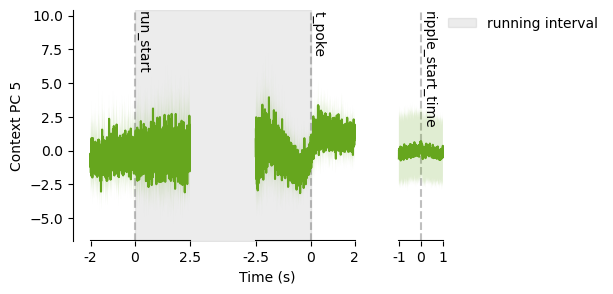

In [57]:
df = trials_df.copy()
# df = df[df.clean_trial]
# df = df[df.trial_type == 'left']
df = df[df.trial_type == 'right']

marks = ["run_start","t_poke", "ripple_start_time"]
windows = [[-2, 2.5], [-2.5, 2], [-1, 1]]
offsets = [0, 8,13]
pc=4


fig = plt.figure(figsize=(5, 3))
ax = fig.add_subplot(111)
tic_locs = []
tic_labels = []
for mark, window, offset in zip(marks, windows, offsets):
    if "ripple" in mark:
        mark = mark.replace("ripple_", "")
        t_mark = ripple_df[mark].values

    else:
        t_mark = df[mark].values
    results = analysis.alligned_response(t_mark, t_plot=window,pca=True)
    mid = np.median(results,axis=0)
    lo = np.percentile(results, 25, axis=0)
    hi = np.percentile(results, 75, axis=0)

    color = plt.cm.Dark2(pc/8)
    t_plot = np.linspace(window[0], window[1], mid.shape[0]) + offset
    plt.plot(t_plot, mid[:,pc],color=color)
    plt.fill_between(t_plot, lo[:,pc], hi[:,pc], alpha=.2, facecolor=color)

    tic = np.array([window[0], 0, window[1]])
    tic_locs.extend(tic+offset)
    labels = [
        window[0] if window[0] != -.5 else "-.5",
        0,
        window[1] if window[1] != .5 else ".5"
    ]
    tic_labels.extend(labels)

ylim = ax.get_ylim()
ylim_top = ylim[1] * 1.2



for mark, window, offset in zip(marks, windows, offsets):
    ax.axvline(offset, color="grey", linestyle="--", zorder=-1, alpha=0.5)
    xx = np.array([window[0], window[1]])
    ax.plot(xx + offset, [ylim[0]] * len(xx), color="k")
    ax.text(offset + 0.05, ylim_top * 0.99, mark, ha="left", va="top", rotation=-90)

plt.xticks(tic_locs, tic_labels)
ax.spines[["top", "right", "bottom"]].set_visible(False)

ax.fill_between([offsets[0], offsets[1]], [ylim[0]] * 2, [ylim_top] * 2, color="grey",
                alpha=0.15, zorder=-1, label = "running interval")
ax.set_ylim(ylim)
ax.set_ylim(ylim[0], ylim_top)
ax.set_ylabel(f"Context PC {pc+1}")
ax.set_xlabel("Time (s)")

fig.legend(
    frameon=False,
    bbox_to_anchor=(1.2, .9),
)
fig.savefig(fig_dir / f"alligned_context_pc{pc+1}.svg", dpi=300, bbox_inches="tight")


## 2d Binned position

In [19]:
results, bx, by = analysis.bin_context_by_feature_2d(
    feature_1 = pos_df_2d["position_x"].values,
    feature_2 = pos_df_2d["position_y"].values,
    feature_1_times = pos_df_2d.index.values,
    feature_2_times = pos_df_2d.index.values,
    pca=True,
    bins_1 = 50,
    bins_2 = 50

)

mid = np.empty((len(bx)-1, len(by)-1, analysis.context_dim))
for i in range(bx.shape[0]-1):
    for j in range(by.shape[0]-1):
        mid[i,j] = np.mean(results[i][j],axis=0)




/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


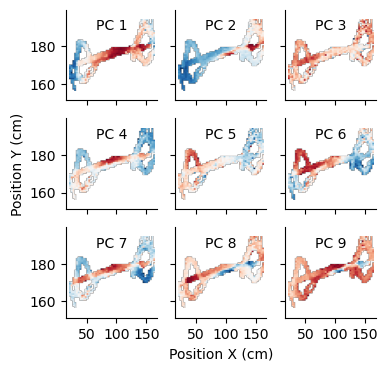

In [20]:
# pc = 0
# plt.imshow(mid[:,:,pc].T, origin='lower', aspect='auto', extent=[bx[0], bx[-1], by[0], by[-1]], cmap='viridis')
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(4,4),sharex=True, sharey=True)

for pc, a in enumerate(ax.flatten()):
    im = a.imshow(mid[:,:,pc].T, origin='lower', aspect='auto', extent=[bx[0], bx[-1], by[0], by[-1]],
                  cmap='RdBu', rasterized=True, )
    a.spines[['top', 'right']].set_visible(False)
    yloc = by[-1]
    xloc = np.mean([bx[0], bx[-1]])
    a.text(xloc, yloc, f"PC {pc+1}",  ha='center', va='top', fontsize=10)
    # a.set_title(f"PC {pc+1}", fontsize=10, pad=-10)
    # a.set_title(f"Context PC {pc+1}")
    # a.set_xlabel("Position X (cm)")
    # a.set_ylabel("Position Y (cm)")
    # fig.colorbar(im, ax=a, orientation='vertical', label='Median Context Value')

pad = 5
a.set_xlim(bx[0]-pad, bx[-1]+pad)
a.set_ylim(by[0]-pad, by[-1]+pad)

ax[-1,1].set_xlabel("Position X (cm)")
ax[1,0].set_ylabel("Position Y (cm)")

fig.subplots_adjust(hspace=0.2, wspace=0.2)

fig.savefig(fig_dir / f"context_pc_position_map.svg", dpi=300, bbox_inches="tight")

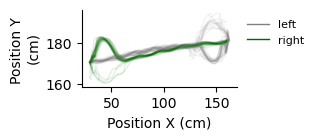

In [ ]:
colors = ['grey' ,'darkgreen']

fig = plt.figure(figsize=(2,1))
ax = fig.add_subplot(111)
for i, row in trials_df.iterrows():
    trial_type = row['trial_type']
    color = colors[0] if trial_type == 'left' else colors[1]
    ind = np.logical_and(pos_df_2d.index >= row['run_start'], pos_df_2d.index <= row['t_poke'])
    plt.plot(pos_df_2d.loc[ind, 'position_x'], pos_df_2d.loc[ind, 'position_y'], color=color, lw=1,
             alpha = .1, label = trial_type if i < 2 else None)

ax.spines[['top', 'right']].set_visible(False)
leg = ax.legend(frameon=False, loc='upper right', fontsize=8, bbox_to_anchor=(1.5, 1),
          )
for handle in leg.legend_handles:
  handle.set_alpha(1.0)
ax.set_xlabel("Position X (cm)")
ax.set_ylabel("Position Y \n(cm)")

fig.savefig(fig_dir / f"position_trajectory.svg", dpi=300, bbox_inches="tight")

# 2d position direction split

In [38]:
pos_vals = pos_df_2d[['position_x','position_y']]

center = (100,170)
rot = -5

theta = np.deg2rad(rot)
rotation_matrix = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)],
])

rotated_pos_vals = (
    (pos_vals.to_numpy() - np.asarray(center)) @ rotation_matrix.T
) + np.asarray(center)

# rotated_pos_vals = pd.DataFrame(
#     rotated_pos_vals,
#     index=pos_vals.index,
#     columns=pos_vals.columns,
# )

In [205]:
left_intervals = trials_df[trials_df.trial_type == 'left'][['run_start', 't_poke']].values
right_intervals = trials_df[trials_df.trial_type == 'right'][['run_start', 't_poke']].values

results, bx, by = analysis.bin_context_by_feature_2d(
    # feature_1 = pos_df_2d["position_x"].values,
    # feature_2 = pos_df_2d["position_y"].values,
    feature_1 = rotated_pos_vals[:,0],
    feature_2 = rotated_pos_vals[:,1],
    feature_1_times = pos_df_2d.index.values,
    feature_2_times = pos_df_2d.index.values,
    pca=True,
    bins_1 = 50,
    bins_2 = 50,
    valid_intervals = left_intervals

)

mid_left = np.empty((len(bx)-1, len(by)-1, analysis.context_dim))
for i in range(bx.shape[0]-1):
    for j in range(by.shape[0]-1):
        mid_left[i,j] = np.mean(results[i][j],axis=0)

results, bx, by = analysis.bin_context_by_feature_2d(
    # feature_1 = pos_df_2d["position_x"].values,
    # feature_2 = pos_df_2d["position_y"].values,
    feature_1 = rotated_pos_vals[:,0],
    feature_2 = rotated_pos_vals[:,1],
    feature_1_times = pos_df_2d.index.values,
    feature_2_times = pos_df_2d.index.values,
    pca=True,
    bins_1 = 50,
    bins_2 = 50,
    valid_intervals = right_intervals

)

mid_right = np.empty((len(bx)-1, len(by)-1, analysis.context_dim))
for i in range(bx.shape[0]-1):
    for j in range(by.shape[0]-1):
        mid_right[i,j] = np.mean(results[i][j],axis=0)

/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


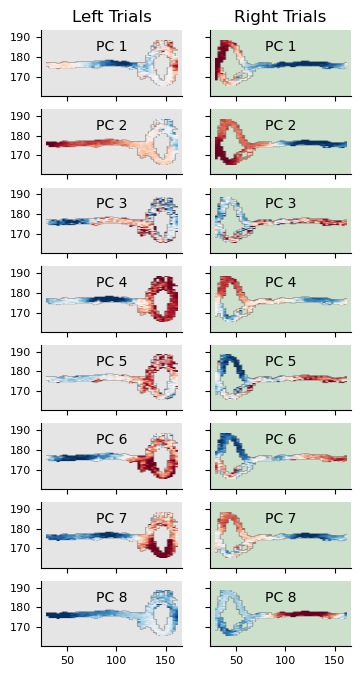

In [206]:
n_plot = 8
fig, ax = plt.subplots(nrows = n_plot, ncols = 2, figsize=(4,1*n_plot), sharex=True, sharey=True)

left_ax = ax[:,0]
right_ax = ax[:,1]
for pc in range(n_plot):
    v_lo = np.nanmin([mid_left[:,:,pc], mid_right[:,:,pc]])
    v_hi = np.nanmax([mid_left[:,:,pc], mid_right[:,:,pc]])

    v_lo = np.nanpercentile([mid_left[:,:,pc], mid_right[:,:,pc]], 5)
    v_hi = np.nanpercentile([mid_left[:,:,pc], mid_right[:,:,pc]], 95)
    for data, a in zip([mid_left, mid_right], [left_ax[pc], right_ax[pc]]):
        im = a.imshow(data[:,:,pc].T, origin='lower', aspect='auto', extent=[bx[0], bx[-1], by[0], by[-1]],
                      cmap='RdBu_r', rasterized=True, clim = (v_lo, v_hi))
        a.spines[['top', 'right']].set_visible(False)
        yloc = by[-1]
        xloc = np.mean([bx[0], bx[-1]])
        a.text(xloc, yloc, f"PC {pc+1}",  ha='center', va='top', fontsize=10)

pad = 5
a.set_xlim(bx[0]-pad, bx[-1]+pad)
a.set_ylim(by[0]-pad, by[-1]+pad)

colors = ['grey' ,'darkgreen']

import matplotlib.colors as mcolors

alpha_colors = [mcolors.to_rgba(c, alpha=0.2) for c in colors]

for a in left_ax:
    a.set_facecolor(alpha_colors[0])
for a in right_ax:
    a.set_facecolor(alpha_colors[1])

left_ax[0].set_title("Left Trials", fontsize=12)
right_ax[0].set_title("Right Trials", fontsize=12)
plt.rcParams['svg.fonttype'] = 'none'
# plt.colorbar(im)
# fig.savefig(fig_dir / f"context_pc_position_map_by_trial_type.svg", dpi=300, bbox_inches="tight")


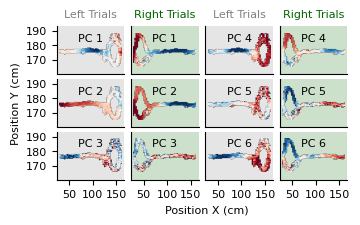

In [ ]:
n_plot = 6
fig, ax = plt.subplots(
    nrows = n_plot//2 , ncols = 4,
    #    figsize=(8,1*n_plot//2),
    figsize = (3.75, .8 * n_plot//2),
    sharex=True, sharey=True)

left_ax = np.concatenate([ax[:,0], ax[:,2]])
right_ax = np.concatenate([ax[:,1], ax[:,3]])
for pc in range(n_plot):
    v_lo = np.nanmin([mid_left[:,:,pc], mid_right[:,:,pc]])
    v_hi = np.nanmax([mid_left[:,:,pc], mid_right[:,:,pc]])

    v_lo = np.nanpercentile([mid_left[:,:,pc], mid_right[:,:,pc]], 5)
    v_hi = np.nanpercentile([mid_left[:,:,pc], mid_right[:,:,pc]], 95)
    for data, a in zip([mid_left, mid_right], [left_ax[pc], right_ax[pc]]):
        im = a.imshow(data[:,:,pc].T, origin='lower', aspect='auto', extent=[bx[0], bx[-1], by[0], by[-1]],
                      cmap='RdBu_r', rasterized=True, clim = (v_lo, v_hi))
        a.spines[['top', 'right']].set_visible(False)
        yloc = by[-1]
        xloc = np.mean([bx[0], bx[-1]])
        a.text(xloc, yloc, f"PC {pc+1}",  ha='center', va='top', fontsize=8)

pad = 5
a.set_xlim(bx[0]-pad, bx[-1]+pad)
a.set_ylim(by[0]-pad, by[-1]+pad)

colors = ['grey' ,'darkgreen']

import matplotlib.colors as mcolors

alpha_colors = [mcolors.to_rgba(c, alpha=0.2) for c in colors]

for a in left_ax:
    a.set_facecolor(alpha_colors[0])
for a in right_ax:
    a.set_facecolor(alpha_colors[1])

for a in np.ravel(ax[:-1]):
    a.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
for a in np.ravel(ax[:,1:]):
    a.tick_params(axis="y", which="both", left=False, labelleft=False)

# left_ax[0].set_title("Left Trials", fontsize=12)
# right_ax[0].set_title("Right Trials", fontsize=12)
for a in [ax[0,0], ax[0,2]]:
    a.set_title("Left Trials", fontsize=8, color=colors[0])
for a in [ax[0,1], ax[0,3]]:
    a.set_title("Right Trials", fontsize=8, color=colors[1])
plt.rcParams['svg.fonttype'] = 'none'


ax[1,0].set_ylabel("Position Y (cm)",ha='center', rotation=90, )
ax[-1,1].set_xlabel("Position X (cm)",ha='left', rotation=0, )
plt.subplots_adjust(hspace=0.1, wspace=0.1)
fig.savefig(fig_dir / f"context_pc_position_map_by_trial_type_2.svg", dpi=300, bbox_inches="tight")

# Theta phase

In [42]:



results, bins = analysis.bin_context_by_feature(
    theta_phase_df.phase.values, theta_phase_df.index.values,
    pca=True,
    bins=np.linspace(0, 2*np.pi, 30),
    valid_intervals = trial_intervals
)
rr = np.array([np.nanpercentile(r, [25, 50, 75],axis=0) for r in results])
mid = rr[:,1]
lo = rr[:,0]
hi = rr[:,2]
# rr.shape

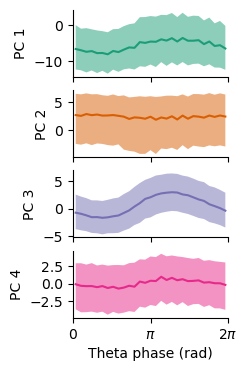

In [45]:
n_plot = 4
fig, ax = plt.subplots(nrows=n_plot, ncols=1, figsize=(2,1*n_plot), sharex=True)
b_plot = (bins[1:] + bins[:-1])/2
for i, a in enumerate(ax):
    color = plt.cm.Dark2(i/8)
    a.plot(b_plot, mid[:,i], color=color)
    a.fill_between(b_plot, lo[:,i], hi[:,i], alpha=.5, facecolor=color, )
    a.spines[["top", "right"]].set_visible(False)
    a.set_ylabel(f"PC {i+1}")
ax[-1].set_xlim(0,2*np.pi)
ax[-1].set_xticks([0, np.pi, 2*np.pi], [0, r"$\pi$", r"$2\pi$"])
ax[-1].set_xlabel("Theta phase (rad)")
fig.savefig(fig_dir / f"theta_phase_avg_context.svg", dpi=300, bbox_inches="tight")

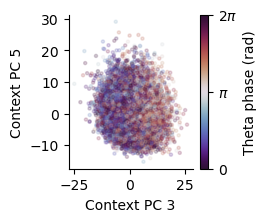

In [49]:
from c3po.analysis.intervals import interval_list_contains_ind


ind_sample = interval_list_contains_ind(trial_intervals, analysis.t)[::10]

# ind_sample = slice(None,None,10)

ind_theta = np.digitize(analysis.t[ind_sample], theta_phase_df.index.values)-1
theta_plot = theta_phase_df.phase.values[ind_theta]

pc_to_plot = (1,2)
# pc_to_plot = (1, 0)
# pc_to_plot = (0,2)
pc_to_plot = (2,4)

fig = plt.figure(figsize=(2,2))
ax = fig.add_subplot(111)
plt.scatter(analysis.c_pca[ind_sample][:, pc_to_plot[0]], analysis.c_pca[ind_sample][:, pc_to_plot[1]],
            s=5,
            c=theta_plot,
            alpha=.2,
            cmap = "twilight_shifted",
            rasterized=True
)
cb = plt.colorbar(label="Theta phase (rad)")
cb.set_ticks([0, np.pi, 2*np.pi])
cb.set_ticklabels([0, r"$\pi$", r"$2\pi$"])
cb.solids.set(alpha=1)
plt.xlabel(f"Context PC {pc_to_plot[0]+1}")
plt.ylabel(f"Context PC {pc_to_plot[1]+1}")
ax.spines[["top", "right"]].set_visible(False)
fig.savefig(fig_dir / f"theta_phase_context_pc{pc_to_plot[0]+1}_{pc_to_plot[1]+1}.svg", dpi=300, bbox_inches="tight")

In [50]:
z_pca = analysis.z @ analysis.pca.components_.T


In [51]:
ind_running = interval_list_contains_ind(all_running_intervals, analysis.t)


theta_running_ind = np.digitize(analysis.t[ind_running], theta_phase_df.index.values)-1
z_running = z_pca[ind_running]
theta_running = theta_phase_df.phase.values[theta_running_ind]


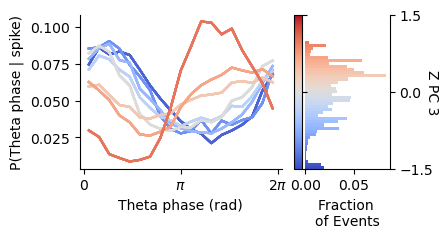

In [110]:
z_bins = np.linspace(-1.5,1.5,10)
theta_bins = np.linspace(0, 2*np.pi, 20)
pc = 2

fig, ax_list = plt.subplots(ncols=2,figsize=(4,2), width_ratios = [3,1])

ax = ax_list [1]
ind_valid = ~(np.isnan(z_running).any(axis=1))
H, bins = np.histogram(z_running[ind_valid][:,pc], bins=50)
H = H/H.sum()
bx = (bins[1:] + bins[:-1])/2
db = np.mean(np.diff(bins))
for i, bb in enumerate(bx):
    color = plt.cm.coolwarm((bb - (-1.5)) / (1.5 - (-1.5)))
    # ax.bar(bb, H[i], color=color, alpha=1, width=db)
    ax.barh(bb, H[i], color=color, alpha=1, height=db)
# ax.set_yscale('log')
# ax_list[0].hist(z_pca[:,pc], bins=100)
ax.set_ylim(-1.5, 1.5)
ax.set_yticks([-1.5,0,1.5],)
ax.set_ylabel("Z PC 3",rotation=270)
ax.set_xlabel("Fraction \nof Events")
ax.spines[["top", "left"]].set_visible(False)
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")

ax = ax_list[0]
results = []
for i in range(z_bins.shape[0]-1):
    for j in range(theta_bins.shape[0]-1):
        ind = np.where(
            (z_running[:,pc] > z_bins[i]) & (z_running[:,pc] < z_bins[i+1])
        )[0]
        if ind.size<100:
            continue
        r, _ = np.histogram(theta_running[ind], bins=theta_bins)
        r = r/np.sum(r)
        results.append(r)
        z_mid = (z_bins[i+1] + z_bins[i])/2
        color = (z_mid - z_bins[0])/(z_bins[-1]-z_bins[0])
        color = plt.cm.coolwarm(color)
        ax.plot((theta_bins[1:] + theta_bins[:-1])/2, r, color=color, alpha=.5,)


ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("Theta phase (rad)")
ax.set_ylabel(f"P(Theta phase | spike)")

cb = plt.colorbar(
    plt.cm.ScalarMappable(cmap="coolwarm"),
    # label=f"Z PC {pc+1}",
    ticks=[0, 0.5, 1],
    # tick_labels=[f"{z_bins[0]:.1f}", f"{(z_bins[0]+z_bins[-1])/2:.1f}", f"{z_bins[-1]:.1f}"],
    # boundaries=[0, 0.5, 1],
    # values=[z_bins[0],  z_bins[-1]],
    ax=ax
)
cb.set_ticklabels([])

ax.set_xticks([0, np.pi, 2*np.pi])
ax.set_xticklabels([0, r"$\pi$", r"$2\pi$"])
fig.subplots_adjust(wspace=-0.16)

# fig.savefig(fig_dir / f"theta_phase_z_pc{pc+1}.svg", dpi=300, bbox_inches="tight")

/tmp/ipykernel_1286516/4195446408.py:89: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=-4,)


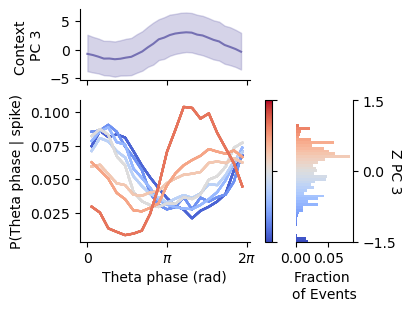

In [126]:
z_bins = np.linspace(-1.5,1.5,10)
theta_bins = np.linspace(0, 2*np.pi, 20)
pc = 2

fig, ax_list = plt.subplots(ncols=2,
                            nrows=2,
                            figsize=(4,3), width_ratios = [3,1],
                            height_ratios=[1,2],
                            sharex="col",
                            layout="constrained",)

ax_list[0,1].set_axis_off()

ax = ax_list[0,0]
results, bins = analysis.bin_context_by_feature(
    theta_phase_df.phase.values, theta_phase_df.index.values,
    pca=True,
    bins=np.linspace(0, 2*np.pi, 30),
    valid_intervals = trial_intervals
)
rr = np.array([np.nanpercentile(r, [25, 50, 75],axis=0) for r in results])
mid = rr[:,1]
lo = rr[:,0]
hi = rr[:,2]
color = plt.cm.Dark2(pc/8)
ax.plot(bins[:-1], mid[:,pc], color=color)
ax.fill_between(bins[:-1], lo[:,pc], hi[:,pc], color=color, alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylabel("Context \nPC 3")




ax = ax_list [1,1]
ind_valid = ~(np.isnan(z_running).any(axis=1))
H, bins = np.histogram(z_running[ind_valid][:,pc], bins=50)
H = H/H.sum()
bx = (bins[1:] + bins[:-1])/2
db = np.mean(np.diff(bins))
for i, bb in enumerate(bx):
    color = plt.cm.coolwarm((bb - (-1.5)) / (1.5 - (-1.5)))
    # ax.bar(bb, H[i], color=color, alpha=1, width=db)
    ax.barh(bb, H[i], color=color, alpha=1, height=db)
# ax.set_yscale('log')
# ax_list[0].hist(z_pca[:,pc], bins=100)
ax.set_ylim(-1.5, 1.5)
ax.set_yticks([-1.5,0,1.5],)
ax.set_ylabel("Z PC 3",rotation=270)
ax.set_xlabel("Fraction \nof Events")
ax.spines[["top", "left"]].set_visible(False)
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")

ax = ax_list[1,0]
results = []
for i in range(z_bins.shape[0]-1):
    for j in range(theta_bins.shape[0]-1):
        ind = np.where(
            (z_running[:,pc] > z_bins[i]) & (z_running[:,pc] < z_bins[i+1])
        )[0]
        if ind.size<100:
            continue
        r, _ = np.histogram(theta_running[ind], bins=theta_bins)
        r = r/np.sum(r)
        results.append(r)
        z_mid = (z_bins[i+1] + z_bins[i])/2
        color = (z_mid - z_bins[0])/(z_bins[-1]-z_bins[0])
        color = plt.cm.coolwarm(color)
        ax.plot((theta_bins[1:] + theta_bins[:-1])/2, r, color=color, alpha=.5,)


ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("Theta phase (rad)")
ax.set_ylabel(f"P(Theta phase | spike)")

cb = plt.colorbar(
    plt.cm.ScalarMappable(cmap="coolwarm"),
    # label=f"Z PC {pc+1}",
    ticks=[0, 0.5, 1],
    # tick_labels=[f"{z_bins[0]:.1f}", f"{(z_bins[0]+z_bins[-1])/2:.1f}", f"{z_bins[-1]:.1f}"],
    # boundaries=[0, 0.5, 1],
    # values=[z_bins[0],  z_bins[-1]],
    ax=ax
)
cb.set_ticklabels([])

ax.set_xticks([0, np.pi, 2*np.pi])
ax.set_xticklabels([0, r"$\pi$", r"$2\pi$"])
fig.subplots_adjust(wspace=-4,)

fig.savefig(fig_dir / f"theta_phase_z_pc{pc+1}.svg", dpi=300, bbox_inches="tight")

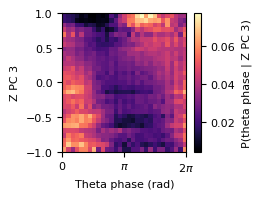

In [ ]:
# plt.scatter( theta_running, z_running[:,pc], alpha = .05, s=10, marker ='|')
# plt.ylim(-1,1)

fig = plt.figure(figsize=(2,1.8))
H, _, _ = np.histogram2d(theta_running, z_running[:,pc],

                         bins = [np.linspace(0, 2*np.pi, 30), np.linspace(-1., 1., 30)])

# H = np.log10(H + 1)
H = H/np.sum(H, axis=0, keepdims=True)
plt.imshow(H.T, aspect='auto', origin='lower', extent=[0, 2*np.pi, -1, 1],cmap = "magma")
plt.colorbar(label = "P(theta phase | Z PC 3)")
plt.xlabel("Theta phase (rad)")
plt.xticks([0, np.pi, 2*np.pi], [0, r"$\pi$", r"$2\pi$"])
plt.ylabel("Z PC 3")
fig.savefig(fig_dir / f"theta_phase_z_pc{pc+1}_HEATMAP.svg", dpi=300, bbox_inches="tight")

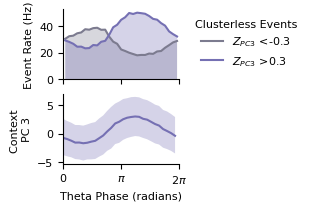

In [ ]:
z_bins = np.linspace(-1.5,1.5,10)
theta_bins = np.linspace(0, 2*np.pi, 30)
pc = 2

plt.rcParams['font.size'] = 8
fig, ax_list = plt.subplots(ncols=1,
                            nrows=2,
                            figsize=(3,2),# width_ratios = [3,1],
                            height_ratios=[1,1],
                            sharex="col",
                            layout="constrained",)

ax = ax_list[0]
H, _ = np.histogram(theta_running, bins=theta_bins)
d_theta = np.mean(np.diff(theta_phase_df.index.values))
occupancy = H * d_theta


thresh = .3
for sign in [-1, 1]:
    if sign>0:
        ind = z_running[:,pc] > thresh
    else:
        ind = z_running[:,pc] < -thresh
    theta_sample = theta_running[ind]
    H, _ = np.histogram(theta_sample, bins=theta_bins)
    bx = (theta_bins[1:] + theta_bins[:-1])/2
    color = plt.cm.Dark2(pc/8)
    if sign < 0:
            from matplotlib.colors import to_rgb
            rgb = np.array(to_rgb(color))
            gray = .5
            amount = .7
            color = tuple((1 - amount) * rgb + amount * gray)

        # label = f"Z PC {pc+1} {'>' if sign > 0 else '<'}{sign}"
    label = f"$Z_{{PC {pc+1}}}$ {'>' if sign > 0 else '<'}{thresh * sign}"

    H = H/occupancy
    ax.plot(bx, H, label=label, color=color)
    ax.fill_between(bx,0, H, alpha=0.3, facecolor=color, zorder = -5)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylabel('Event Rate (Hz)')
ax.set_ylim(0, ax.get_ylim()[1])
ax.legend(frameon=False, title = "Clusterless Events", bbox_to_anchor=(1.05, 1))


ax = ax_list[1]
results, bins = analysis.bin_context_by_feature(
    theta_phase_df.phase.values, theta_phase_df.index.values,
    pca=True,
    bins=np.linspace(0, 2*np.pi, 30),
    valid_intervals = trial_intervals
)
rr = np.array([np.nanpercentile(r, [25, 50, 75],axis=0) for r in results])
mid = rr[:,1]
lo = rr[:,0]
hi = rr[:,2]
color = plt.cm.Dark2(pc/8)
ax.plot(bins[:-1], mid[:,pc], color=color)
ax.fill_between(bins[:-1], lo[:,pc], hi[:,pc], facecolor=color, alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylabel("Context \nPC 3")
ax.set_xticks([0, np.pi, 2*np.pi], ["0", r"$\pi$", r"$2\pi$"])
ax.set_xlim(0, 2*np.pi)
ax.set_xlabel('Theta Phase (radians)')
fig.savefig(fig_dir /  f"theta_phase_z_pc{pc+1}_SIMPLE.svg")